# Neural Network Curve Fit with Fourier Feature Maps

## Goal

Choose a Fourier feature map, train a neural network on noisy observations, and look far into the future to decide whether the predicted curve still matches simulated data.

The network sees only the gray observed points. The orange future points are generated **after** the training range and are not used to train the model. The dashed sine curve is shown only as a reference.

The Fourier map converts each input into repeating features:

$$
\sin\left(k\frac{2\pi x}{P}\right),\qquad
\cos\left(k\frac{2\pi x}{P}\right),
$$

where $k$ is a harmonic and $P$ is the assumed period. Because these features repeat, they can help a model make periodic predictions far beyond the observed range.


## Setup: choose the parameters

Change the values in the next cell, then use **Kernel → Restart Kernel and Run All Cells**.

### Fourier feature controls

| Parameter | What it changes | Good values to try |
|---|---|---|
| `USE_FOURIER_FEATURES` | Turns the Fourier map on or off | `True`, `False` |
| `FOURIER_HARMONICS` | Uses harmonics from 1 through this number | 1, 3, 6, 10 |
| `FOURIER_PERIOD_IN_CYCLES` | Assumed repetition period | 0.8, 1.0, 1.2, 2.0 |
| `INCLUDE_RAW_X` | Adds the ordinary input beside Fourier features | `False`, `True` |

### Data and network controls

| Parameter | What it changes | Good values to try |
|---|---|---|
| `OBSERVED_CYCLES` | How much history the model sees | 1, 2, 4, 6 |
| `FUTURE_CYCLES` | How far ahead the simulation runs | 5, 10, 20 |
| `OBSERVED_POINTS` | Number of training observations | 60, 120, 240, 500 |
| `NOISE_STD` | How scattered the data are | 0.00, 0.10, 0.25 |
| `HIDDEN_LAYERS` | Number of hidden layers | 1, 2, 3 |
| `NEURONS_PER_LAYER` | Size of each hidden layer | 8, 16, 32, 64 |
| `ACTIVATION` | Shape used inside the network | `"tanh"`, `"relu"`, `"logistic"` |

This notebook uses NumPy, Matplotlib, and scikit-learn. If needed, install them with `pip install numpy matplotlib scikit-learn`.


In [1]:
# ============================================================
# STUDENT SETTINGS: change values here, then run all cells
# ============================================================

RANDOM_SEED = 42

# Data and future simulation
OBSERVED_CYCLES = 2
FUTURE_CYCLES = 10
OBSERVED_POINTS = 240
FUTURE_POINTS_PER_CYCLE = 30
NOISE_STD = 0.10

# Fourier feature map
USE_FOURIER_FEATURES = True
FOURIER_HARMONICS = 3
FOURIER_PERIOD_IN_CYCLES = 1.0
INCLUDE_RAW_X = False

# Neural-network shape
HIDDEN_LAYERS = 1
NEURONS_PER_LAYER = 16
ACTIVATION = "tanh"          # "tanh", "relu", or "logistic"

# Training
TRAINING_ITERATIONS = 500
LEARNING_RATE = 0.003


## Step 1: create observed and future data

The observed data cover the first few cycles. The future simulation begins immediately after the last observed point and continues for the number of cycles selected above.


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive.*")

if OBSERVED_CYCLES <= 0 or FUTURE_CYCLES <= 0:
    raise ValueError("OBSERVED_CYCLES and FUTURE_CYCLES must be positive.")
if OBSERVED_POINTS < 10 or FUTURE_POINTS_PER_CYCLE < 2:
    raise ValueError("Use at least 10 observed points and 2 future points per cycle.")
if NOISE_STD < 0:
    raise ValueError("NOISE_STD cannot be negative.")

rng = np.random.default_rng(RANDOM_SEED)
cycle_length = 2 * np.pi
observed_end = OBSERVED_CYCLES * cycle_length
future_end = (OBSERVED_CYCLES + FUTURE_CYCLES) * cycle_length

x_observed = np.linspace(0, observed_end, OBSERVED_POINTS).reshape(-1, 1)
y_observed = np.sin(x_observed[:, 0]) + rng.normal(0, NOISE_STD, OBSERVED_POINTS)

future_point_count = FUTURE_CYCLES * FUTURE_POINTS_PER_CYCLE
future_step = cycle_length / FUTURE_POINTS_PER_CYCLE
x_future_data = np.linspace(
    observed_end + future_step,
    future_end,
    future_point_count,
).reshape(-1, 1)
y_future_data = np.sin(x_future_data[:, 0]) + rng.normal(
    0,
    NOISE_STD,
    future_point_count,
)

print(f"Observed range: 0 to {OBSERVED_CYCLES} cycles ({OBSERVED_POINTS} points)")
print(f"Future range: {OBSERVED_CYCLES} to {OBSERVED_CYCLES + FUTURE_CYCLES} cycles "
      f"({future_point_count} new points)")


Observed range: 0 to 2 cycles (240 points)
Future range: 2 to 12 cycles (300 new points)


## Step 2: build the feature map and train the network

When Fourier features are enabled, every input is replaced by sine and cosine pairs at the selected harmonics. The optional raw input can be included as one additional feature.

The assumed period matters. The simulated relationship repeats every `1.0` cycle, so that is the matching value. Try a slightly different value later and watch the phase drift accumulate in the future.


In [3]:
if HIDDEN_LAYERS < 1 or NEURONS_PER_LAYER < 1:
    raise ValueError("Use at least one hidden layer and one neuron per layer.")
if ACTIVATION not in {"tanh", "relu", "logistic"}:
    raise ValueError('ACTIVATION must be "tanh", "relu", or "logistic".')
if TRAINING_ITERATIONS < 1 or LEARNING_RATE <= 0:
    raise ValueError("TRAINING_ITERATIONS and LEARNING_RATE must be positive.")
if FOURIER_HARMONICS < 1:
    raise ValueError("FOURIER_HARMONICS must be at least 1.")
if FOURIER_PERIOD_IN_CYCLES <= 0:
    raise ValueError("FOURIER_PERIOD_IN_CYCLES must be positive.")

x_center = x_observed.mean()
x_scale = x_observed.std()

feature_names = []
if INCLUDE_RAW_X or not USE_FOURIER_FEATURES:
    feature_names.append("scaled raw x")
if USE_FOURIER_FEATURES:
    for harmonic in range(1, FOURIER_HARMONICS + 1):
        feature_names.extend([f"sin({harmonic} phase)", f"cos({harmonic} phase)"])

def make_features(values):
    values = np.asarray(values).reshape(-1, 1)
    feature_columns = []

    if INCLUDE_RAW_X or not USE_FOURIER_FEATURES:
        feature_columns.append((values - x_center) / x_scale)

    if USE_FOURIER_FEATURES:
        period_in_x_units = FOURIER_PERIOD_IN_CYCLES * cycle_length
        phase = 2 * np.pi * values / period_in_x_units
        for harmonic in range(1, FOURIER_HARMONICS + 1):
            feature_columns.append(np.sin(harmonic * phase))
            feature_columns.append(np.cos(harmonic * phase))

    return np.hstack(feature_columns)

observed_features = make_features(x_observed)
layer_shape = (NEURONS_PER_LAYER,) * HIDDEN_LAYERS
network = MLPRegressor(
    hidden_layer_sizes=layer_shape,
    activation=ACTIVATION,
    solver="adam",
    learning_rate_init=LEARNING_RATE,
    max_iter=TRAINING_ITERATIONS,
    random_state=RANDOM_SEED,
    tol=1e-8,
    n_iter_no_change=TRAINING_ITERATIONS + 1,
)
network.fit(observed_features, y_observed)

if USE_FOURIER_FEATURES:
    map_description = (
        f"Fourier harmonics 1-{FOURIER_HARMONICS}, "
        f"period {FOURIER_PERIOD_IN_CYCLES:g} cycle(s), "
        f"raw x {'included' if INCLUDE_RAW_X else 'excluded'}"
    )
else:
    map_description = "Raw x only"

print(f"Feature map: {map_description}")
print(f"Features per input point: {observed_features.shape[1]} ({', '.join(feature_names)})")
print(f"Network shape: {HIDDEN_LAYERS} hidden layer(s), "
      f"{NEURONS_PER_LAYER} neurons each, {ACTIVATION} activation")
print(f"Training finished after {network.n_iter_} iterations")


Feature map: Fourier harmonics 1-3, period 1 cycle(s), raw x excluded
Features per input point: 6 (sin(1 phase), cos(1 phase), sin(2 phase), cos(2 phase), sin(3 phase), cos(3 phase))
Network shape: 1 hidden layer(s), 16 neurons each, tanh activation
Training finished after 500 iterations


In [ ]:
train_predictions = network.predict(observed_features)
training_loss = np.mean((train_predictions - y_observed) ** 2)

print(f"Training loss (MSE on observed data): {training_loss:.6f}")

# Alias for consistency with validation block naming.
scale_x = make_features

## Step 3: compare the Fourier-based curve with future data

The left panel checks the observed range. The right panel extends the same prediction through the full future simulation. With a matching Fourier period, the input features repeat in the same way at every cycle.


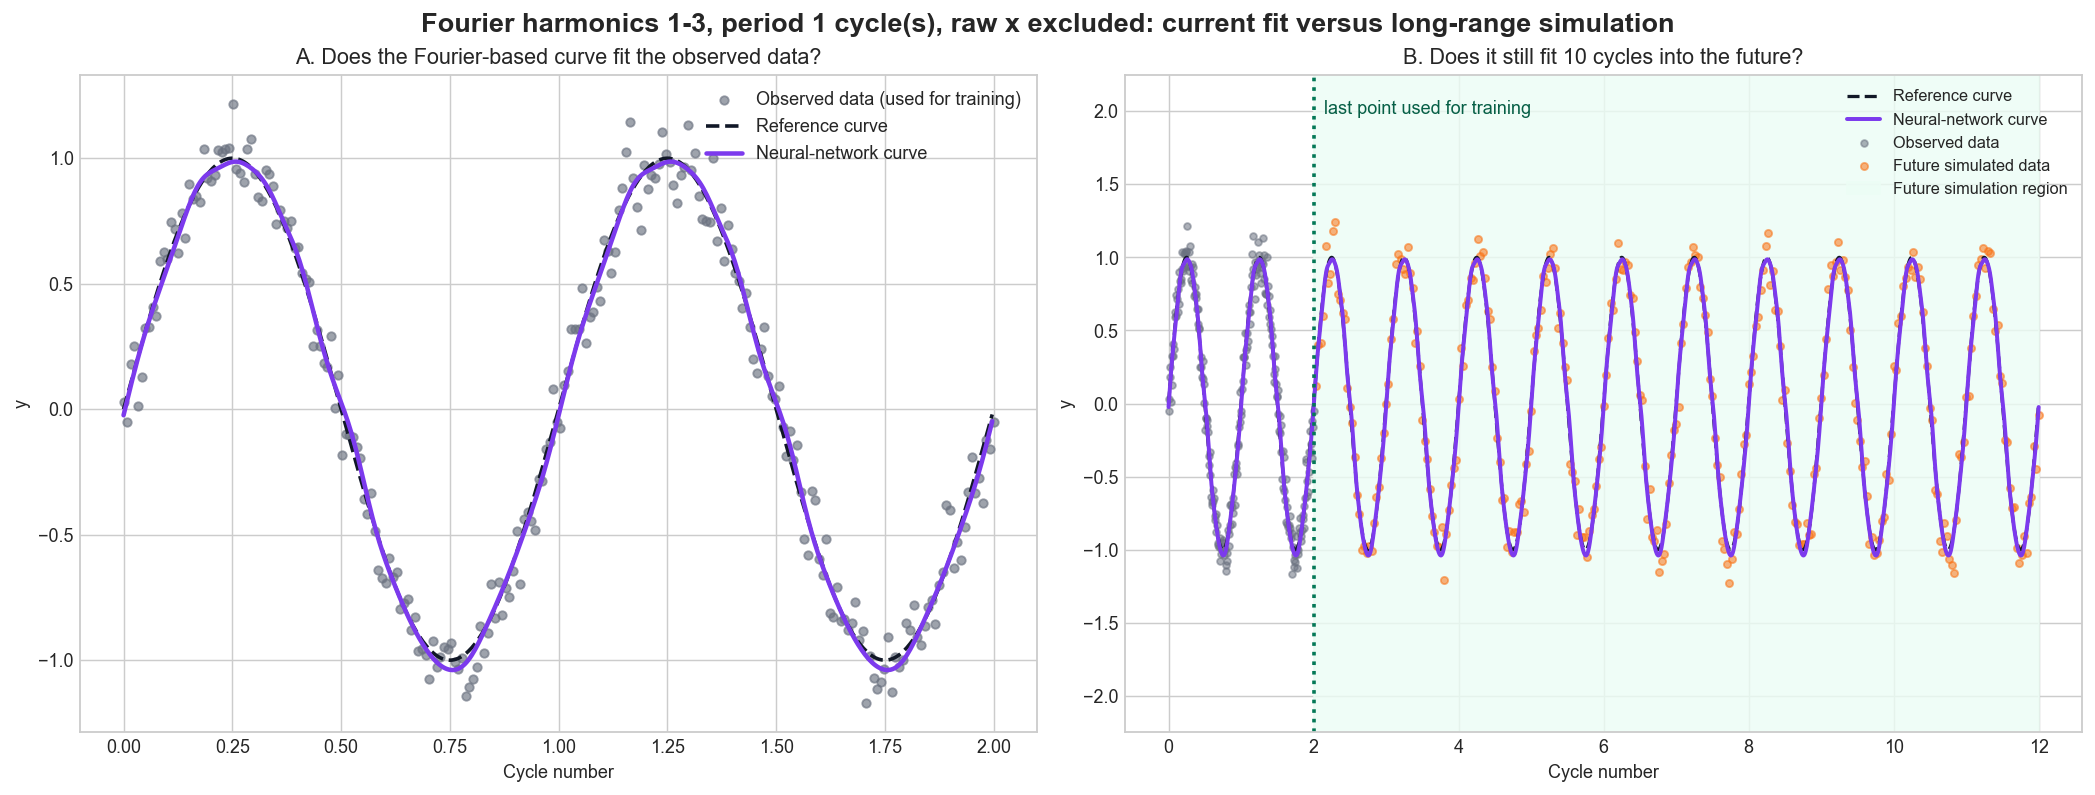

In [4]:
curve_point_count = max(2000, (OBSERVED_CYCLES + FUTURE_CYCLES) * 250)
x_curve = np.linspace(0, future_end, curve_point_count).reshape(-1, 1)
y_network_curve = network.predict(make_features(x_curve))
y_reference_curve = np.sin(x_curve[:, 0])
curve_cycles = x_curve[:, 0] / cycle_length
observed_mask = x_curve[:, 0] <= observed_end

plt.style.use("seaborn-v0_8-whitegrid")
fig, (fit_ax, future_ax) = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    constrained_layout=True,
)

fit_ax.scatter(
    x_observed[:, 0] / cycle_length,
    y_observed,
    s=22,
    color="#6b7280",
    alpha=0.65,
    label="Observed data (used for training)",
)
fit_ax.plot(
    curve_cycles[observed_mask],
    y_reference_curve[observed_mask],
    color="#111827",
    linestyle="--",
    linewidth=2,
    label="Reference curve",
)
fit_ax.plot(
    curve_cycles[observed_mask],
    y_network_curve[observed_mask],
    color="#7c3aed",
    linewidth=2.5,
    label="Neural-network curve",
)
fit_ax.set_title("A. Does the Fourier-based curve fit the observed data?")
fit_ax.set_xlabel("Cycle number")
fit_ax.set_ylabel("y")
fit_ax.legend(loc="upper right")

future_ax.axvspan(
    OBSERVED_CYCLES,
    OBSERVED_CYCLES + FUTURE_CYCLES,
    color="#ecfdf5",
    alpha=0.8,
    label="Future simulation region",
)
future_ax.plot(
    curve_cycles,
    y_reference_curve,
    color="#111827",
    linestyle="--",
    linewidth=1.8,
    label="Reference curve",
)
future_ax.plot(
    curve_cycles,
    y_network_curve,
    color="#7c3aed",
    linewidth=2.2,
    label="Neural-network curve",
)
future_ax.scatter(
    x_observed[:, 0] / cycle_length,
    y_observed,
    s=14,
    color="#6b7280",
    alpha=0.55,
    label="Observed data",
)
future_ax.scatter(
    x_future_data[:, 0] / cycle_length,
    y_future_data,
    s=16,
    color="#f97316",
    alpha=0.55,
    label="Future simulated data",
)
future_ax.axvline(
    OBSERVED_CYCLES,
    color="#047857",
    linestyle=":",
    linewidth=2,
)
future_ax.text(
    OBSERVED_CYCLES,
    2.08,
    "  last point used for training",
    color="#065f46",
    va="top",
)
future_ax.set_title(f"B. Does it still fit {FUTURE_CYCLES} cycles into the future?")
future_ax.set_xlabel("Cycle number")
future_ax.set_ylabel("y")
future_ax.set_ylim(-2.25, 2.25)

future_predictions = y_network_curve[~observed_mask]
if np.max(np.abs(future_predictions)) > 2.25:
    future_ax.text(
        0.99,
        0.02,
        "The purple forecast leaves the visible data range.",
        transform=future_ax.transAxes,
        ha="right",
        va="bottom",
        color="#b91c1c",
        bbox={"facecolor": "white", "edgecolor": "#fecaca", "alpha": 0.9},
    )

handles, labels = future_ax.get_legend_handles_labels()
legend_order = [1, 2, 3, 4, 0]
future_ax.legend(
    [handles[index] for index in legend_order],
    [labels[index] for index in legend_order],
    loc="upper right",
    fontsize=9,
)

fig.suptitle(
    f"{map_description}: current fit versus long-range simulation",
    fontsize=15,
    fontweight="bold",
)
plt.show()


In [ ]:
validation_predictions = network.predict(scale_x(x_future_data))
validation_loss = np.mean((validation_predictions - y_future_data) ** 2)

print(f"Validation loss (MSE on future simulated data): {validation_loss:.6f}")

## Checks: what should you look for?

1. **Observed fit:** In panel A, does the purple curve pass through the middle of the gray data?
2. **Near future:** Just after the vertical divider, is the purple curve close to the orange points?
3. **Far future:** Near the right edge, are the peaks and valleys still aligned?
4. **Phase drift:** If the assumed Fourier period is slightly wrong, does the purple curve move progressively out of step with the future data?

Fourier features do not discover the correct period automatically. They encode a period chosen in the settings. A strong long-range result therefore depends on whether that assumption matches the data.


## Next steps: Fourier feature experiments

Change one setting at a time and rerun the notebook.

| Experiment | Change | Question to answer from the graph |
|---|---|---|
| Raw input only | `USE_FOURIER_FEATURES = False` | How does the long-range curve compare? |
| Fundamental frequency only | `FOURIER_HARMONICS = 1` | Is one sine/cosine pair enough for this data? |
| More harmonics | `FOURIER_HARMONICS = 6` or `10` | Does extra flexibility help or chase noise? |
| Period too short | `FOURIER_PERIOD_IN_CYCLES = 0.9` | How does the phase drift appear? |
| Period too long | `FOURIER_PERIOD_IN_CYCLES = 1.1` | Does the drift reverse direction? |
| Add raw position | `INCLUDE_RAW_X = True` | Does the curve remain periodic far ahead? |
| Much farther ahead | `FUTURE_CYCLES = 20` | Is a small period error easier to see? |
| More noise | `NOISE_STD = 0.25` | Do higher harmonics follow the pattern or the noise? |

Record each run:

| Run | Fourier settings | Fits observed data? | Fits near future? | Fits far future? | What happened? |
|---:|---|---|---|---|---|
| 1 |  |  |  |  |  |
| 2 |  |  |  |  |  |
| 3 |  |  |  |  |  |
